In [1]:
import pandas as pd 
import numpy as np 
import torch
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

In [3]:
########### 4 ways to Handle Regime shifts:-
#1.Sliding window  (Instead of training on all historical data, train only on the most recent observations.)
#2.Encoding Memory (model remembar past regimes | LSTM, GRU, Transformers, Attention)
#3.Online Learning (update the model continuously==== SGDClassifier, Online Gradient Desent, Online Random Forest, Adaptive Boosting)
#4.Policy Gradient Reinforcement Learning (Reinforce, ppo, a2c, ddpg, sag)


## What is Stationarity ?
# Stationarity is where the statical properties of the time series in constant - that it is invariant over time.
# mean + variance + skewness(distribution is tilted to one side( +ve in right)) + kurtosis(how heavy the tails are)


In [4]:
#df = pd.read_csv("C:/Users/Mritunjay Maddhesiya/OneDrive/Desktop/Research_Paper/11_Forecasting_Position_Model/data/XAU_Daily_20_26.csv")
df = pd.read_csv("C:/Users/Mritunjay Maddhesiya/OneDrive/Desktop/Research_Paper/4_Time_Series/1m_SOL.csv")
#df["Date"]    = pd.to_datetime(df["Date"], format="%d-%m-%Y ",errors="coerce")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df  = df.rename(columns={"Price": "Close", "Vol.": "Volume"})
price_columns = ["Open", "High", "Low", "Close"]

for col in price_columns:
    df[col] = (df[col].astype(str).str.replace(",","",regex=False))
    df[col] = pd.to_numeric(df[col], errors="coerce")
df['Close_return'] = df['Close'].pct_change()
df.head()

,Open,High,Low,Close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base,taker_buy_quote,ignore,bid_volume,ask_volume,total_volume,Close_return
Date,,,,,,,,,,,,,,,
2025-01-01 00:00:00,189.22,192.58,189.00,192.44,586540.0,2025-01-01 00:59:59.999,1.119673e+08,68555,359295.0,6.857010e+07,0,359295.0,227245.0,586540.0,NaN
2025-01-01 01:00:00,192.44,192.56,190.25,190.62,334974.0,2025-01-01 01:59:59.999,6.406374e+07,44264,152790.0,2.922456e+07,0,152790.0,182184.0,334974.0,-0.009457
2025-01-01 02:00:00,190.63,191.96,190.31,191.51,204131.0,2025-01-01 02:59:59.999,3.899926e+07,32475,107411.0,2.052400e+07,0,107411.0,96720.0,204131.0,0.004669
2025-01-01 03:00:00,191.52,191.52,189.93,190.31,180453.0,2025-01-01 03:59:59.999,3.440564e+07,26172,71486.0,1.362997e+07,0,71486.0,108967.0,180453.0,-0.006266
2025-01-01 04:00:00,190.31,190.31,189.25,189.41,275678.0,2025-01-01 04:59:59.999,5.230004e+07,35493,130134.0,2.468810e+07,0,130134.0,145544.0,275678.0,-0.004729


<Axes: >

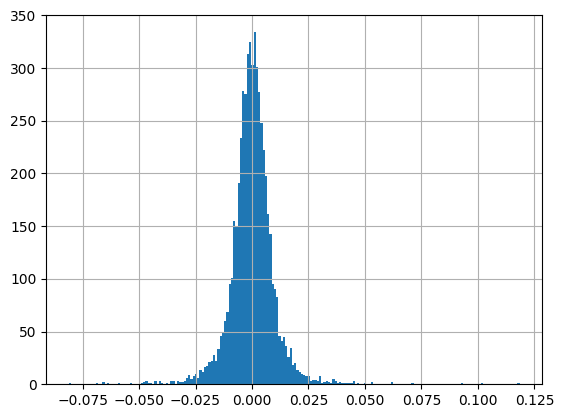

In [5]:
df['Close_return'].hist(bins=200)

In [6]:
df.aggregate({'Close_return' : ['mean', 'std', 'skew', 'kurt']})

,Close_return
mean,0.000043
std,0.009853
skew,0.443761
kurt,13.411031


In [7]:
from scipy.stats import kurtosis

stats = df.groupby(df.index.year)['Close_return'].agg(
    Mean='mean',
    Std='std',
    Skew='skew',
    Kurtosis=lambda x: kurtosis(x, fisher=False)
)
stats

,Mean,Std,Skew,Kurtosis
Date,,,,
2025,0.000043,0.009853,0.443761,NaN


<Axes: xlabel='Date'>

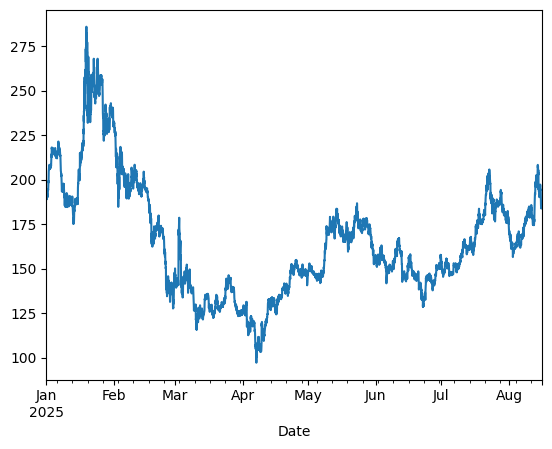

In [8]:
yearly_return = df.groupby(df.index.year)['Close'].agg(Annual_Return=lambda x: x.iloc[-1] / x.iloc[0] - 1)
yearly_return
df['Close'].plot()


In [9]:
## How to handle non-stationarity in supervised learning
## Let's build a model to predict future returns using the current return - (this is called an auto-regressive model.)

df['close_log_return'] = np.log(df['Close'] / df['Close'].shift())
df['close_log_return_lag_1'] = df['close_log_return'].shift()

In [10]:
def backtest_model(df, features, target, test_split = 0.25):
    df = df.dropna()
    df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)

    X_train, X_test, y_train, y_test = df_train[features], df_test[features], df_train[target], df_test[target]

    model = LinearRegression()
    model.fit(X_train, y_train)
    print(model.coef_, model.intercept_)

    backtest = df.copy()
    backtest['y_hat'] = model.predict(backtest[features])
    backtest['signal'] = np.sign(backtest['y_hat'])
    backtest['trade_log_return'] = backtest['close_log_return'] * backtest['signal']
    backtest['cum_trade_log_return'] = backtest['trade_log_return'].cumsum()
    backtest['cum_trade_log_return'].plot()

    return model, backtest


[-0.04271544] -6.576703069834085e-05


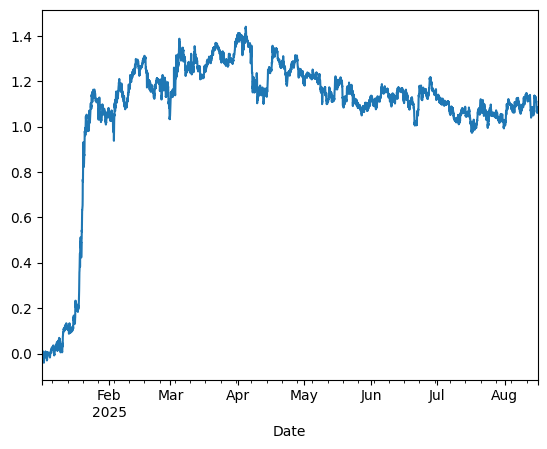

In [11]:
model, backtest = backtest_model(df, ['close_log_return_lag_1'], 'close_log_return')

<Axes: xlabel='Date'>

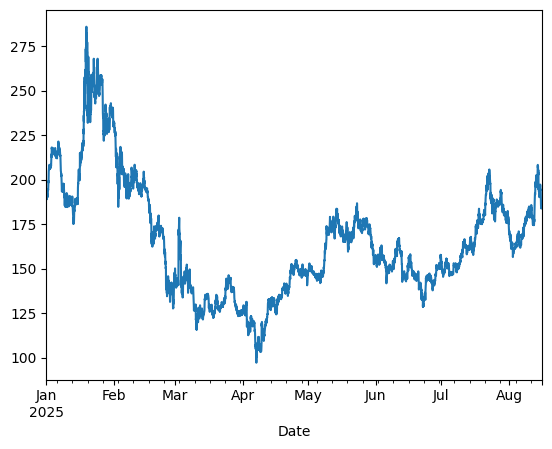

In [12]:
df['Close'].plot()

In [13]:
print(backtest['signal'].value_counts())
# print("")
# print(backtest['y_hat'].describe())
# print("")
# print(backtest[['close_log_return_lag_1', 'close_log_return', 'y_hat', 'signal']].head(20))

signal
-1.0    3221
 1.0    2229
Name: count, dtype: int64


In [14]:
######################## Sliding Window ##########################
### 1. window size matters

####################### Encode Memory #############################
### Take raw, noisy sequence of past returns and compresses it into a signal, continuous hidden state


In [15]:
df['close_log_return_ma_lag_1'] = df['close_log_return_lag_1'].rolling(20).mean()
df.tail()

,Open,High,Low,Close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base,taker_buy_quote,ignore,bid_volume,ask_volume,total_volume,Close_return,close_log_return,close_log_return_lag_1,close_log_return_ma_lag_1
Date,,,,,,,,,,,,,,,,,,
2025-08-15 23:00:00,187.61,188.18,184.04,185.62,1283433.43,2025-08-15 23:59:59.999,2.385183e+08,147514,593700.84,1.103945e+08,0,593700.84,689732.59,1283433.43,-0.010554,-0.010610,0.011203,-0.001497
2025-08-16 00:00:00,185.61,187.69,185.21,187.35,796148.79,2025-08-16 00:59:59.999,1.486273e+08,110572,415105.33,7.748935e+07,0,415105.33,381043.46,796148.79,0.009320,0.009277,-0.010610,-0.002488
2025-08-16 01:00:00,187.35,188.06,186.39,187.84,673376.20,2025-08-16 01:59:59.999,1.260805e+08,84203,340307.20,6.373231e+07,0,340307.20,333069.00,673376.20,0.002615,0.002612,0.009277,-0.001975
2025-08-16 02:00:00,187.83,187.98,186.76,186.80,612522.72,2025-08-16 02:59:59.999,1.147099e+08,83508,268649.36,5.031059e+07,0,268649.36,343873.36,612522.72,-0.005537,-0.005552,0.002612,-0.002233
2025-08-16 03:00:00,186.81,188.25,186.61,187.02,623731.59,2025-08-16 03:59:59.999,1.169821e+08,76140,295477.78,5.542479e+07,0,295477.78,328253.81,623731.59,0.001178,0.001177,-0.005552,-0.002732


[-0.07548205] -7.405312681898739e-05


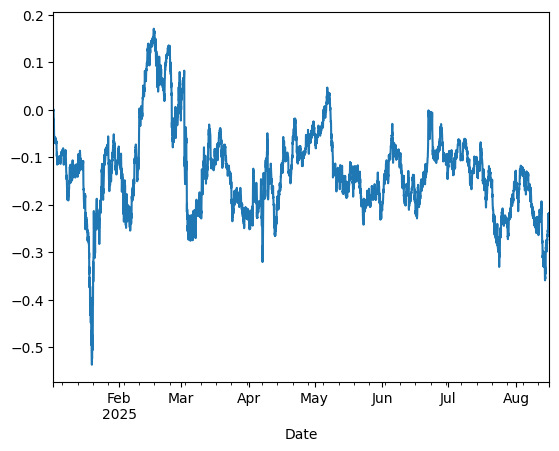

In [16]:
model, backtest = backtest_model(df, ['close_log_return_ma_lag_1'], 'close_log_return')

In [17]:
backtest['signal'].value_counts()

signal
-1.0    3845
 1.0    1586
Name: count, dtype: int64

[-0.04107429 -0.03600477] -7.420598713477943e-05


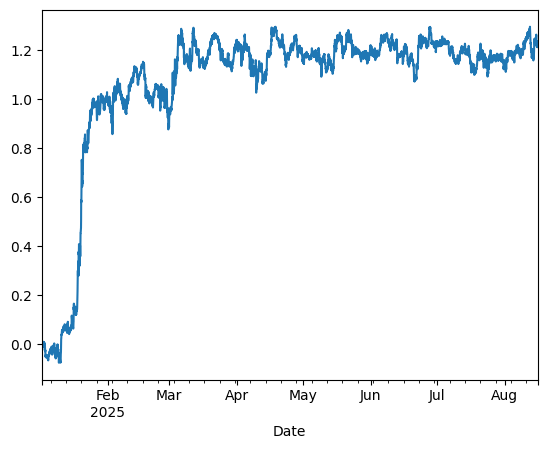

In [18]:
model, backtest = backtest_model(df, ['close_log_return_lag_1', 'close_log_return_ma_lag_1'], 'close_log_return')

In [19]:
backtest['signal'].value_counts()

signal
-1.0    3285
 1.0    2146
Name: count, dtype: int64

In [20]:
################## Online Learning ############################
### The passive aggressive regressor is an online linear regression model that update its weights sample-by-sample,remaining
### completely passive if its prediction error falls within an acceptable, user-defined errors margin. if the error exceeds that margin, it
### reacts aggressively by making the smallest possible adjustment to its weight vector to accurately fit that new point, capped by a 
### regularization parameter C to prevent sudden noise from ruining past learning.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

####### DATA ###########
df_clean = df.dropna()
features = ['close_log_return_lag_1']
target   = 'close_log_return'

X_stream = df_clean[features].to_numpy()
y_stream = df_clean[target].to_numpy()

####### Initialize update online learning components ---
#### Using SGDRegressor configured for native Passive-Aggressive updates
model = SGDRegressor(loss="epsilon_insensitive", 
                      epsilon=0.0002,      ## The acceptable error margin(passive threshold)
                      penalty=None,        ### Pure PA doesn't use L1/L2 shrinkage penalties
                      learning_rate="pa1", ### Uses PA-2 update rules
                      eta0=0.01,           ### Acts as parameter C(maximum step size cap)
                      random_state=69
)
scaler = StandardScaler()

### List to collect structural and evaluation records row-by-row
records = []

###### Pure streaming Loop ##########
for t in range(len(X_stream)):
    x_t = X_stream[t].reshape(1, -1)
    y_t = np.array([y_stream[t]])

    ### scale feature vector incrementally based on live variance shifts
    scaler.partial_fit(x_t)
    x_t_scaled = scaler.transform(x_t)

    ## A. test step: predict before updating weights
    if t == 0:
        pred_y = 0.0  
    else:
        pred_y = model.predict(x_t_scaled)[0]

    ### Evaluate direction accuracy
    if t>0 and y_t[0] != 0 and pred_y != 0:
        sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"
    else:
        sign_match = "Warmup"

    ## B. train step: update weights dynamically via SGD single-sample steps
    model.partial_fit(x_t_scaled, y_t)

    ## Extract structural components safely from SGDRegressor
    current_weight = model.coef_[0]
    current_bias   = model.intercept_[0]

    ## calculate signal and if won or not in the tick
    signal = np.sign(pred_y)
    trade_log_return = signal * y_t[0]

    ### Record the complete state context at this tick
    if sign_match != "Warmup":
        records.append({
            'tick': t,
            'lag_1_x': x_t[0][0],
            'true_y': y_t[0],
            
        })